In [ ]:
import numpy as np
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import re
from datetime import datetime
import json
from plot_utils import *

In [2]:
mpl.rcParams.update(RC_PARAMS)

In [3]:
ROOT = (Path(__vsc_ipynb_file__).parents[1] / "scripts/")
POINTWISE = ROOT / "CKM1D_Pointwise"
PARAMSTUDY = ROOT / "CKM1D_ParameterStudy"

In [4]:
def select_latest_runs(
    all_runs: list[Path],
    ids: list[str],
    tag: str,
    format: str = "csv"
) -> dict[str, Path]:

    selected_runs = {}

    for run_id in ids:
        pattern = re.compile(
            rf"^{re.escape(run_id)}_{re.escape(tag)}_"
            rf"(?P<date>\d{{8}})_(?P<time>\d{{6}})\.{format}$"
        )

        matching_runs = []

        for path in all_runs:
            match = pattern.match(path.name)

            if match is None:
                continue

            timestamp = datetime.strptime(
                match.group("date") + match.group("time"),
                "%Y%m%d%H%M%S",
            )

            matching_runs.append((timestamp, path))

        if matching_runs:
            _, latest_path = max(matching_runs, key=lambda item: item[0])
            selected_runs[run_id] = latest_path
        else:
            print(f"Nincs megfelelő run: {run_id}_{tag}")

    return selected_runs

# 2-bubble system

In [5]:
COLORS = {
    "bubble_0": "#D55E00",   # vermilion
    "bubble_1": "#0072B2",   # blue
    "bubble_2": "#1CC82D",   # green
    "bubble_3": "#C81CA3"    # magenta
}

REF_STYLE = {
    "lw": 3.2,
    "alpha": 0.32,
    "solid_capstyle": "round",
    "zorder": 2,
}

GPU_STYLE = {
    "lw": 1.15,
    "alpha": 1.0,
    "solid_capstyle": "round",
    "zorder": 3,
}

In [6]:
all_runs = sorted({p for p in POINTWISE.rglob("*.csv")})

## Figure 2

In [7]:
ID_FIG2 = ["2-a", "2-b", "2-c", "2-d", "2-e", "2-f"]
TAG_FIG2= "NS_4096_SPB_32_NDO_2048_numba_warp"
fig2_runs = select_latest_runs(all_runs, ids=ID_FIG2, tag=TAG_FIG2)
fig2_runs

{'2-a': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_Pointwise/2-a_NS_4096_SPB_32_NDO_2048_numba_warp_20260723_123327.csv'),
 '2-b': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_Pointwise/2-b_NS_4096_SPB_32_NDO_2048_numba_warp_20260723_125013.csv'),
 '2-c': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_Pointwise/2-c_NS_4096_SPB_32_NDO_2048_numba_warp_20260723_131542.csv'),
 '2-d': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_Pointwise/2-d_NS_4096_SPB_32_NDO_2048_numba_warp_20260723_133053.csv'),
 '2-e': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_Pointwise/2-e_NS_4096_SPB_32_NDO_2048_numba_warp_20260723_134733.csv'),
 '2-f': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_Pointwise/2-f_NS_4096_SPB_32_NDO_2048_numba_warp_20260723_140522.csv')}

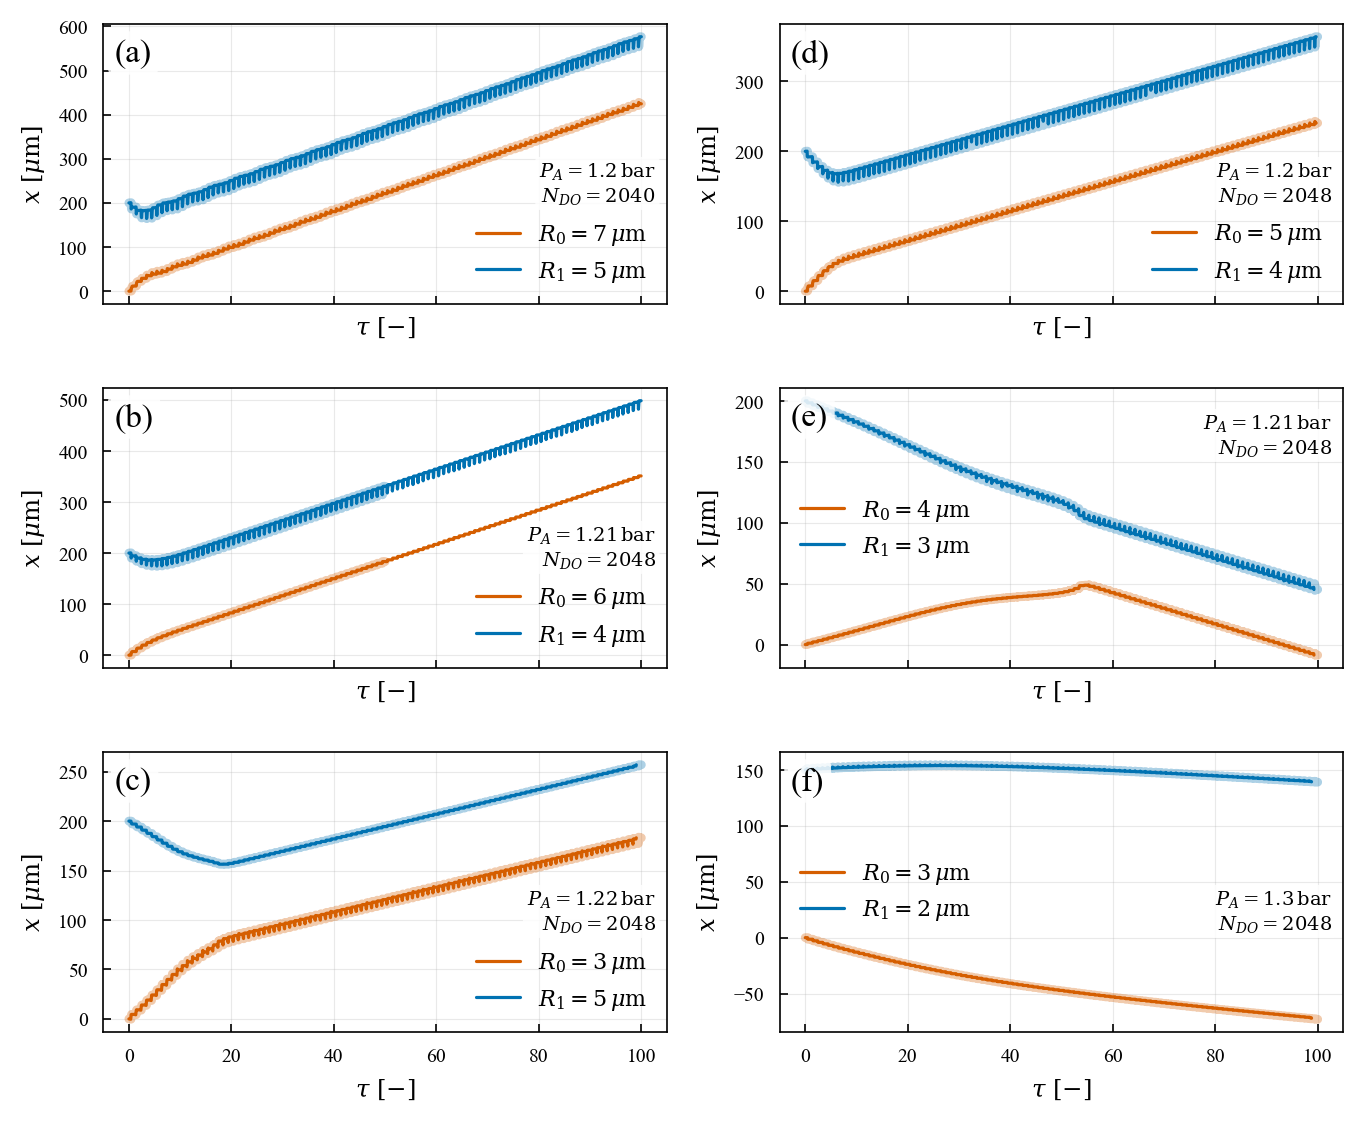

In [8]:
PA = [1.2, 1.21, 1.22, 1.2, 1.21, 1.3]
R0 = [7.0, 6.0, 3.0, 5.0, 4.0, 3.0]
R1 = [5.0, 4.0, 5.0, 4.0, 3.0, 2.0]
REF = ["Fig2_a", "Fig2_b", "Fig2_c", "Fig2_d", "Fig2_e", "Fig2_f"  ]
Y_OFFSET = [0.35, 0.35, 0.35, 0.35, 0.75, 0.35]
LEGEND_LOC = ["lower right", "lower right", "lower right", "lower right", "center left", "center left"]

nrows, ncols = 3, 2
(fig_w, fig_h), adj = two_column_figsize(nrows, ncols, width_in=7.0, panel_height_in=1.40, wspace=0.2, hspace=0.3)
with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=True, sharey=False)
    axs = axes.T.ravel()

    for i, run in enumerate(fig2_runs.values()):
        arr = np.loadtxt(run, delimiter=",", skiprows=1)
        ref = np.loadtxt(POINTWISE / "ref" / f"{REF[i]}.txt")

        t_s, R0_um, R1_um, x0_um, x1_um = arr.T
        rt_s, rR0_um, rR1_um, rX0_um, rX1_um = ref.T

        ndo = len(t_s)
        ax = axs[i]

        ax.plot(rt_s, rX0_um * 1e6, color=COLORS["bubble_0"], **REF_STYLE)
        ax.plot(rt_s, rX1_um * 1e6, color=COLORS["bubble_1"], **REF_STYLE)

        ax.plot(t_s, x0_um, color=COLORS["bubble_0"], label=rf"$R_0={R0[i]:g}\,\mu\mathrm{{m}}$",**GPU_STYLE)
        ax.plot(t_s, x1_um, color=COLORS["bubble_1"], label=rf"$R_1={R1[i]:g}\,\mu\mathrm{{m}}$", **GPU_STYLE)
        ax.grid(True, which="major", linewidth=0.4, alpha=0.28, zorder=0)
        ax.tick_params(axis="both",which="major", direction="in",length=3,width=0.6,labelsize=7)
        ax.set_ylabel(r"$x\ [\mu\mathrm{m}]$")
        ax.set_xlabel(r"$\tau\ [-]$")

        info = (
            fr"$P_A={PA[i]:.3g}\,\mathrm{{bar}}$"
            "\n"
            fr"$N_{{DO}}={ndo}$"
        )

        axs[i].text(
            0.98, Y_OFFSET[i], info,
            transform=axs[i].transAxes,  # tengelyarányos koordináta: (0..1, 0..1)
            ha="right", va="bottom",
            fontsize=7,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85),
        )

        axs[i].text(
            0.02, 0.95, f"({chr(97+i)})",
            transform=axs[i].transAxes,
            ha="left", va="top",
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)
        )

        # A buborékok jelmagyarázata
        axs[i].legend(loc=LEGEND_LOC[i])

fig.subplots_adjust(**adj)
fig.savefig("figs/verification_1.pdf", bbox_inches="tight")
fig.savefig("figs/verification_1.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 3

In [9]:
ID_FIG3 = ["3-a", "3-b"]
TAG_FIG3= "NS_4096_SPB_32_NDO_2048_numba_warp"
fig3_runs = select_latest_runs(all_runs, ids=ID_FIG3, tag=TAG_FIG3)
fig3_runs

{'3-a': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_Pointwise/3-a_NS_4096_SPB_32_NDO_2048_numba_warp_20260723_140932.csv'),
 '3-b': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_Pointwise/3-b_NS_4096_SPB_32_NDO_2048_numba_warp_20260723_141109.csv')}

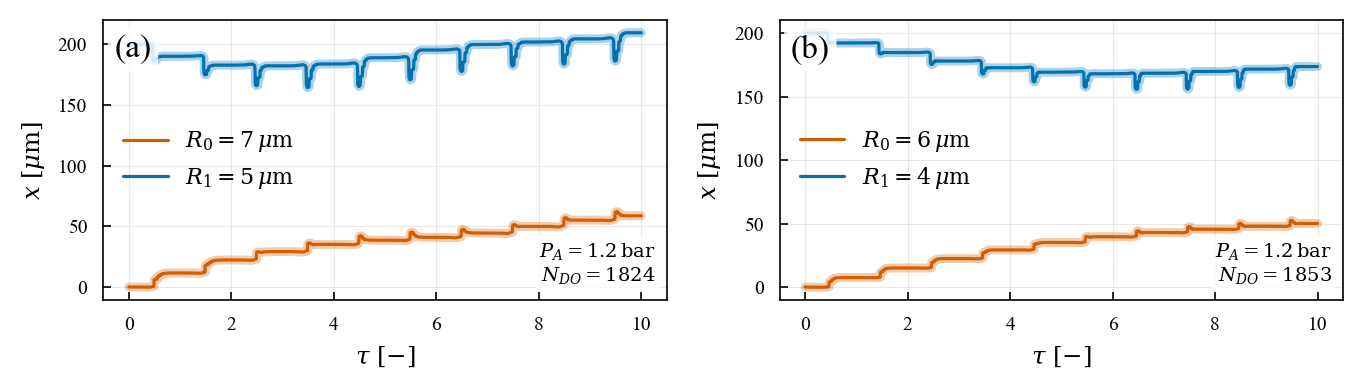

In [10]:
PA = [1.2, 1.2]
R0 = [7.0, 6.0]
R1 = [5.0, 4.0]
REF = ["Fig3_a", "Fig3_b"]
Y_OFFSET = [0.05, 0.05]
LEGEND_LOC = ["center left", "center left"]
nrows, ncols = 1, 2
(fig_w, fig_h), adj = two_column_figsize(nrows, ncols, width_in=7.0, panel_height_in=1.40, wspace=0.2, hspace=0.3)
with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=True, sharey=False)
    axs = axes.ravel()

    for i, run in enumerate(fig3_runs.values()):
        arr = np.loadtxt(run, delimiter=",", skiprows=1)
        ref = np.loadtxt(POINTWISE / "ref" / f"{REF[i]}.txt")

        t_s, R0_um, R1_um, x0_um, x1_um = arr.T
        rt_s, rR0_um, rR1_um, rX0_um, rX1_um = ref.T

        ndo = len(t_s)
        ax = axs[i]

        ax.plot(rt_s, rX0_um * 1e6, color=COLORS["bubble_0"], **REF_STYLE)
        ax.plot(rt_s, rX1_um * 1e6, color=COLORS["bubble_1"], **REF_STYLE)

        ax.plot(t_s, x0_um, color=COLORS["bubble_0"], label=rf"$R_0={R0[i]:g}\,\mu\mathrm{{m}}$",**GPU_STYLE)
        ax.plot(t_s, x1_um, color=COLORS["bubble_1"], label=rf"$R_1={R1[i]:g}\,\mu\mathrm{{m}}$", **GPU_STYLE)
        ax.grid(True, which="major", linewidth=0.4, alpha=0.28, zorder=0)
        ax.tick_params(axis="both",which="major", direction="in",length=3,width=0.6,labelsize=7)
        ax.set_ylabel(r"$x\ [\mu\mathrm{m}]$")
        ax.set_xlabel(r"$\tau\ [-]$")

        info = (
            fr"$P_A={PA[i]:.3g}\,\mathrm{{bar}}$"
            "\n"
            fr"$N_{{DO}}={ndo}$"
        )

        axs[i].text(
            0.98, Y_OFFSET[i], info,
            transform=axs[i].transAxes,  # tengelyarányos koordináta: (0..1, 0..1)
            ha="right", va="bottom",
            fontsize=7,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85),
        )

        axs[i].text(
            0.02, 0.95, f"({chr(97+i)})",
            transform=axs[i].transAxes,
            ha="left", va="top",
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)
        )

        # A buborékok jelmagyarázata
        axs[i].legend(loc=LEGEND_LOC[i])

fig.subplots_adjust(**adj)
fig.savefig("figs/verification_2.pdf", bbox_inches="tight")
fig.savefig("figs/verification_2.png", dpi=300, bbox_inches="tight")
plt.show()


## Figure 4

In [11]:
ID_FIG4 = ["4-a", "4-b"]
TAG_FIG4= "NS_4096_SPB_32_NDO_2048_numba_warp"
fig4_runs = select_latest_runs(all_runs, ids=ID_FIG4, tag=TAG_FIG4)
fig4_runs

{'4-a': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_Pointwise/4-a_NS_4096_SPB_32_NDO_2048_numba_warp_20260723_141913.csv'),
 '4-b': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_Pointwise/4-b_NS_4096_SPB_32_NDO_2048_numba_warp_20260723_142049.csv')}

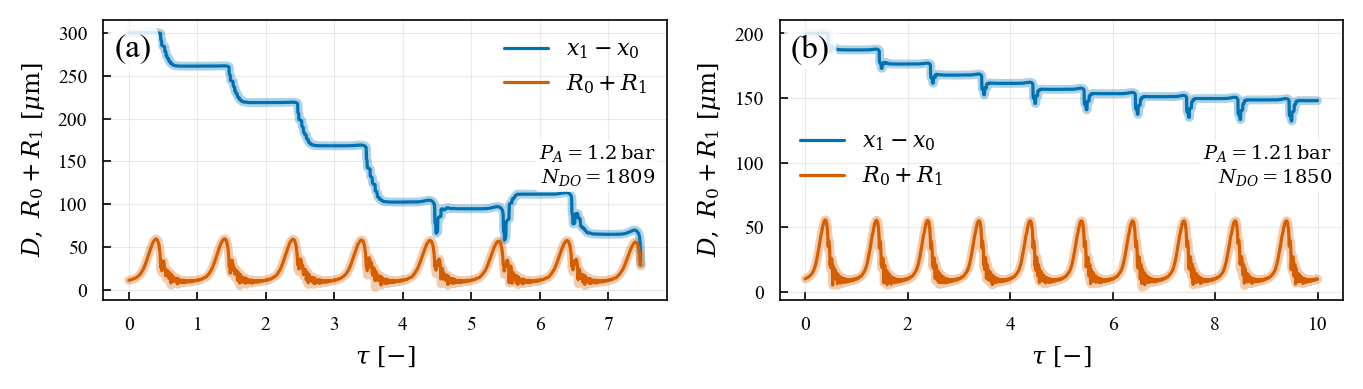

In [12]:
PA = [1.2, 1.21]
R0 = [6.0, 6.0]
R1 = [5.0, 4.0]
REF = ["Fig4_a", "Fig4_b"]
Y_OFFSET = [0.40, 0.40]
LEGEND_LOC = ["upper right", "center left"]

nrows, ncols = 1, 2
(fig_w, fig_h), adj = two_column_figsize(nrows, ncols, width_in=7.0, panel_height_in=1.40, wspace=0.2, hspace=0.3)
with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=False, sharey=False)
    axs = axes.T.ravel()

    for i, run in enumerate(fig4_runs.values()):
        arr = np.loadtxt(run, delimiter=",", skiprows=1)
        ref = np.loadtxt(POINTWISE / "ref" / f"{REF[i]}.txt")

        t_s, R0_um, R1_um, x0_um, x1_um = arr.T
        rt_s, rR0_um, rR1_um, rX0_um, rX1_um = ref.T

        ndo = len(t_s)
        ax = axs[i]

        #ax.plot(rt_s, rX0_um * 1e6, color=COLORS["bubble_0"], **REF_STYLE)
        ax.plot(rt_s, (rX1_um - rX0_um) * 1e6, color=COLORS["bubble_1"], **REF_STYLE)
        ax.plot(rt_s, (rR0_um + rR1_um) * 1e6, color=COLORS["bubble_0"], **REF_STYLE)

        #ax.plot(t_s, x0_um, color=COLORS["bubble_0"], label=rf"$R_0={R0[i]:g}\,\mu\mathrm{{m}}$",**GPU_STYLE)
        ax.plot(t_s, (x1_um - x0_um), color=COLORS["bubble_1"], label=rf"$x_1-x_0$", **GPU_STYLE)
        ax.plot(t_s, (R0_um + R1_um), color=COLORS["bubble_0"], label=rf"$R_0+R_1$", **GPU_STYLE)

        ax.grid(True, which="major", linewidth=0.4, alpha=0.28, zorder=0)
        ax.tick_params(axis="both",which="major", direction="in",length=3,width=0.6,labelsize=7)
        ax.set_ylabel(r"$D,\ R_0+R_1\ [\mu\mathrm{m}]$")
        ax.set_xlabel(r"$\tau\ [-]$")

        info = (
            fr"$P_A={PA[i]:.3g}\,\mathrm{{bar}}$"
            "\n"
            fr"$N_{{DO}}={ndo}$"
        )

        axs[i].text(
            0.98, Y_OFFSET[i], info,
            transform=axs[i].transAxes,  # tengelyarányos koordináta: (0..1, 0..1)
            ha="right", va="bottom",
            fontsize=7,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85),
        )

        axs[i].text(
            0.02, 0.95, f"({chr(97+i)})",
            transform=axs[i].transAxes,
            ha="left", va="top",
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)
        )

        # A buborékok jelmagyarázata
        axs[i].legend(loc=LEGEND_LOC[i])

fig.subplots_adjust(**adj)
fig.savefig("figs/verification_3.pdf", bbox_inches="tight")
fig.savefig("figs/verification_3.png", dpi=300, bbox_inches="tight")
plt.show()


# Parameter Study

In [13]:
all_runs = sorted({p for p in PARAMSTUDY.rglob("*.npz")})
all_runs

[WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/16B_PA1_TEST_NS_1024_SPB_4_NDO_1024_numba_warp_20260724_155637.npz'),
 WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/2B_PA1_CASE1_NS_4096_SPB_32_NDO_4096_numba_warp_20260722_151153.npz'),
 WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/2B_PA1_CASE2_NS_4096_SPB_32_NDO_4096_numba_warp_20260722_152159.npz'),
 WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/2B_PA1_CASE3_NS_4096_SPB_32_NDO_4096_numba_warp_20260722_152920.npz'),
 WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/32B_PA1_TEST_NS_1024_SPB_4_NDO_1024_numba_warp_20260724_161102.npz'),
 WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/3B_PA1_CASE1_NS_4096_SPB_32_NDO_4096_numba_warp

In [14]:
ID = ["2B_PA1_CASE2", "3B_PA1_CASE2", "4B_PA1_CASE2"]
TAG = "NS_4096_SPB_32_NDO_4096_numba_warp"
runs = select_latest_runs(all_runs, ids=ID, tag=TAG, format="npz")
runs

{'2B_PA1_CASE2': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/2B_PA1_CASE2_NS_4096_SPB_32_NDO_4096_numba_warp_20260722_152159.npz'),
 '3B_PA1_CASE2': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/3B_PA1_CASE2_NS_4096_SPB_32_NDO_4096_numba_warp_20260722_155350.npz'),
 '4B_PA1_CASE2': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/4B_PA1_CASE2_NS_4096_SPB_32_NDO_4096_numba_warp_20260722_141540.npz')}

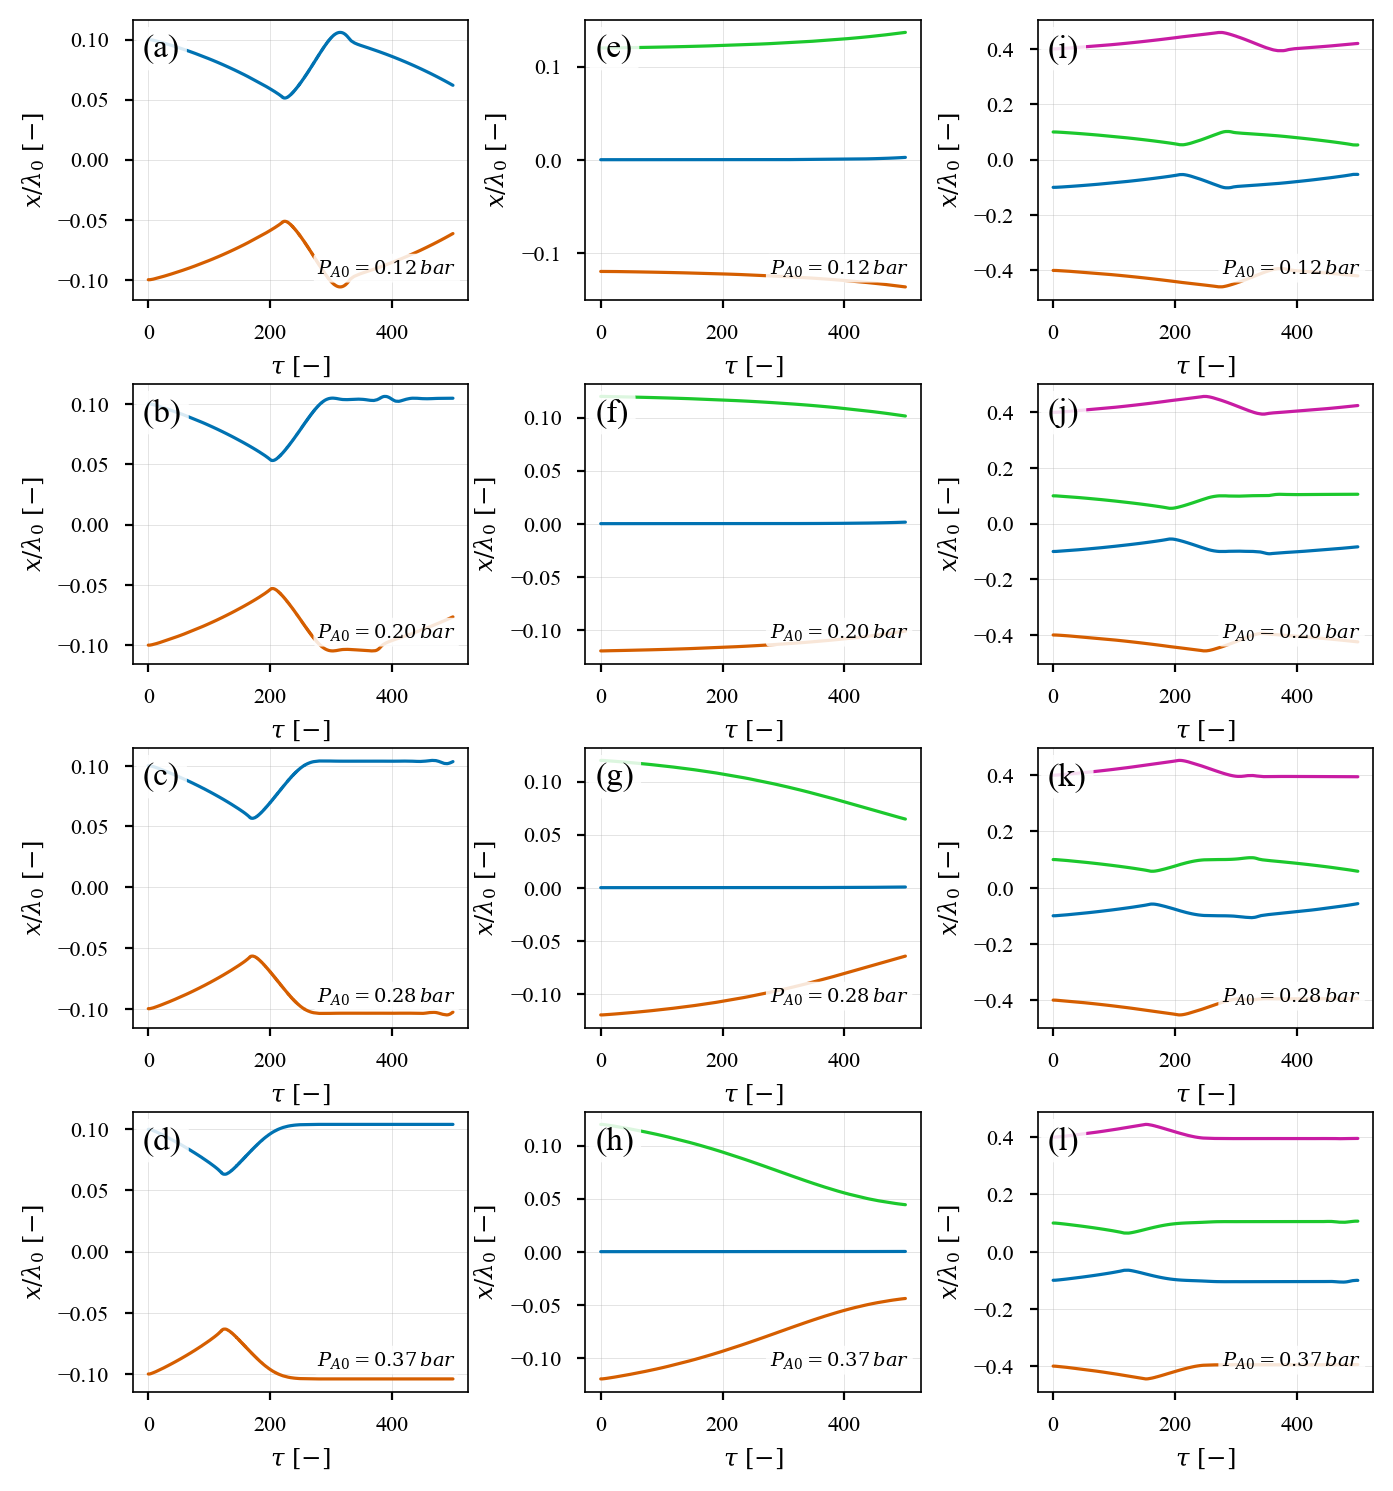

In [15]:
nrows, ncols = 4, 3
sel    = np.linspace(500, 1500, nrows, dtype=np.int64)
(fig_w, fig_h), adj = two_column_figsize(nrows, ncols, width_in=7.0, panel_height_in=1.40, wspace=0.35, hspace=0.3)
panel_counter = 0
with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=False, sharey=False)

    for j, run in enumerate(runs.values()):
        data = np.load(run)
        dense_index = data["dense_index"]
        dense_time  = data["dense_time"]
        dense_state = data["dense_state"]
        pa0_range = np.linspace(0, 1.0, len(dense_index))
        
        for i in range(nrows):
            system_id = sel[i]
            npts = dense_index[system_id]
            t = dense_time[:npts, system_id]
            ups = 2 + j     # 2, 3, 4

            for unit_id in range(ups):
                x = dense_state[:npts, 1, system_id, unit_id]
                axes[i, j].plot(t, x, label=f"Bubble {unit_id}", color=COLORS[f"bubble_{unit_id}"], **GPU_STYLE)

            axes[i, j].grid(True, which="both", linewidth=0.3, alpha=0.4)
            #axs[i].legend(loc="best", fontsize=7)
            axes[i, j].set_ylabel(r"$x/\lambda_0\ [-]$", x=0.02)
            axes[i, j].set_xlabel(r"$\tau\ [-]$") 
            axes[i, j].text(
                0.03, 0.95, f"({chr(97+panel_counter)})",
                transform=axes[i, j].transAxes,
                ha="left", va="top",
                fontsize=12,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)
            )

            axes[i, j].text(
                0.55, 0.15, fr"$P_{{A0}}={pa0_range[system_id]:.2f}\, bar$",
                transform=axes[i, j].transAxes,
                ha="left", va="top",
                fontsize=7,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)
            )

            panel_counter += 1

    fig.subplots_adjust(**adj)

fig.savefig("figs/parameter_study.pdf", bbox_inches="tight")
fig.savefig("figs/parameter_study.png", dpi=300, bbox_inches="tight")
plt.show()

# Scalability

In [16]:
ID = ["5B_PA1_TEST", "16B_PA1_TEST", "32B_PA1_TEST"]
TAG = "NS_1024_SPB_4_NDO_1024_numba_warp"
UPS = [5, 16, 32]
SYSTEMS = [1023, 1023, 1023]
runs = select_latest_runs(all_runs, ids=ID, tag=TAG, format="npz")
runs

{'5B_PA1_TEST': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/5B_PA1_TEST_NS_1024_SPB_4_NDO_1024_numba_warp_20260724_154939.npz'),
 '16B_PA1_TEST': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/16B_PA1_TEST_NS_1024_SPB_4_NDO_1024_numba_warp_20260724_155637.npz'),
 '32B_PA1_TEST': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/32B_PA1_TEST_NS_1024_SPB_4_NDO_1024_numba_warp_20260724_161102.npz')}

In [17]:
metas = {k: run.with_suffix(".json") for k, run in runs.items()}
metas

{'5B_PA1_TEST': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/5B_PA1_TEST_NS_1024_SPB_4_NDO_1024_numba_warp_20260724_154939.json'),
 '16B_PA1_TEST': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/16B_PA1_TEST_NS_1024_SPB_4_NDO_1024_numba_warp_20260724_155637.json'),
 '32B_PA1_TEST': WindowsPath('d:/BubbleDynamics/PositionControl/coupled-bubble-control/scripts/CKM1D_ParameterStudy/32B_PA1_TEST_NS_1024_SPB_4_NDO_1024_numba_warp_20260724_161102.json')}

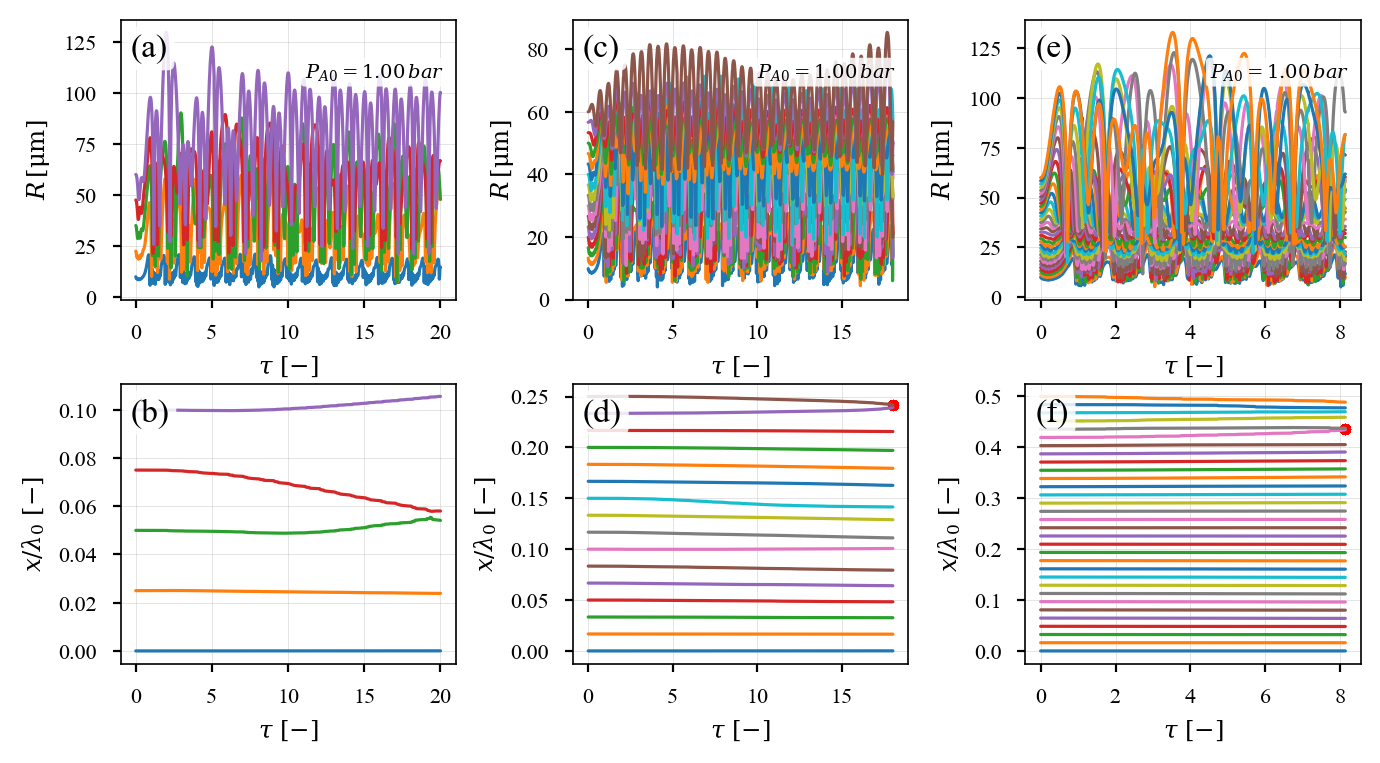

In [20]:
nrows, ncols = 2, 3
(fig_w, fig_h), adj = two_column_figsize(nrows, ncols, width_in=7.0, panel_height_in=1.40, wspace=0.35, hspace=0.3)
with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=False, sharey=False)

    for j, run_name in enumerate(runs.keys()):
        data = np.load(runs[run_name])
        with open(metas[run_name], 'r') as f:
            meta = json.load(f)
            R0 = np.asanyarray([v['values'] for v in meta['scene_parameters']['R0']]).ravel()  # micron

        dense_index = data["dense_index"]
        dense_time  = data["dense_time"]
        dense_state = data["dense_state"]
        pa0_range = np.linspace(0, 1.0, len(dense_index))
        
        system_id = SYSTEMS[j]
        npts = dense_index[system_id]
        t = dense_time[:npts, system_id]

        for unit_id in range(UPS[j]):
            r = dense_state[:npts, 0, system_id, unit_id] * R0[unit_id]
            x = dense_state[:npts, 1, system_id, unit_id]
            axes[0, j].plot(t, r,  label=f"Bubble {unit_id}", **GPU_STYLE)
            axes[1, j].plot(t, x,  label=f"Bubble {unit_id}", **GPU_STYLE)

            # Collision -- set empirically
            if j == 1:
                axes[1, j].plot(t[-1], 0.242, "r.", markersize=8)
            elif j == 2:
                axes[1, j].plot(t[-1], 0.435, "r.", markersize=8)

        #axes[0, j].set_xlim(0, 15)
        axes[0, j].grid(True, which="both", linewidth=0.3, alpha=0.4)
        axes[1, j].grid(True, which="both", linewidth=0.3, alpha=0.4)
        #axs[i].legend(loc="best", fontsize=7)
        axes[0, j].set_ylabel(r"$R\, [\mathrm{\mu m}]$", x=0.02)
        axes[1, j].set_ylabel(r"$x/\lambda_0\ [-]$", x=0.02)
        axes[0, j].set_xlabel(r"$\tau\ [-]$")
        axes[1, j].set_xlabel(r"$\tau\ [-]$") 
        
        axes[0, j].text(
            0.03, 0.95, f"({chr(97+j*nrows)})",
            transform=axes[0, j].transAxes,
            ha="left", va="top",
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)
        )

        axes[1, j].text(
            0.03, 0.95, f"({chr(97+j*nrows+1)})",
            transform=axes[1, j].transAxes,
            ha="left", va="top",
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)
        )

        axes[0, j].text(
            0.55, 0.85, fr"$P_{{A0}}={pa0_range[system_id]:.2f}\, bar$",
            transform=axes[0, j].transAxes,
            ha="left", va="top",
            fontsize=7,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)
        )


    fig.subplots_adjust(**adj)

fig.savefig("figs/scale_up.pdf", bbox_inches="tight")
fig.savefig("figs/scale_up.png", dpi=300, bbox_inches="tight")
plt.show()
